## Plotagem de Gráficos

## Gráfico de Pizza
Vamos começar criando um gráfico de pizza para analisar as mortes causadas pelo vírus Ebola em países da África. O primeiro passo é importar as bibliotecas que serão utilizadas.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

A seguir, vamos fazer o upload do csv que contém os dados.

In [4]:
df = pd.read_csv('datasets/ebola.csv',encoding='latin-1')

In [5]:
df.head()

,Countries,Type,Number_of_cases,Death
0,Guinea,comfirmed cases,3351,2083
1,Guinea,Probable cases,453,453
2,Sierra Leone,comfirmed cases,8704,3589
3,Sierra Leone,Probable cases,287,208
4,Sierra Leone,Suspected cases,5131,158


Agora vamos filtrar apenas os dados de Sierra Leone.

In [6]:
sierra = df[df['Countries'] =='Sierra Leone']
sierra

,Countries,Type,Number_of_cases,Death
2,Sierra Leone,comfirmed cases,8704,3589
3,Sierra Leone,Probable cases,287,208
4,Sierra Leone,Suspected cases,5131,158


Agora vamos gerar o gráfico de pizza de mortes por casos confirmados, prováveis e suspeitos. O primeiro passo é definir em qual coluna estão os dados (sizes - tamanhos do pedaço de pizza), e os rótulos (labels) de cada pedaço da pizza.

In [9]:
sizes = sierra['Death']
labels = sierra['Type']
sizes,labels

(2    3589
 3     208
 4     158
 Name: Death, dtype: int64,
 2    comfirmed cases
 3     Probable cases
 4    Suspected cases
 Name: Type, dtype: str)

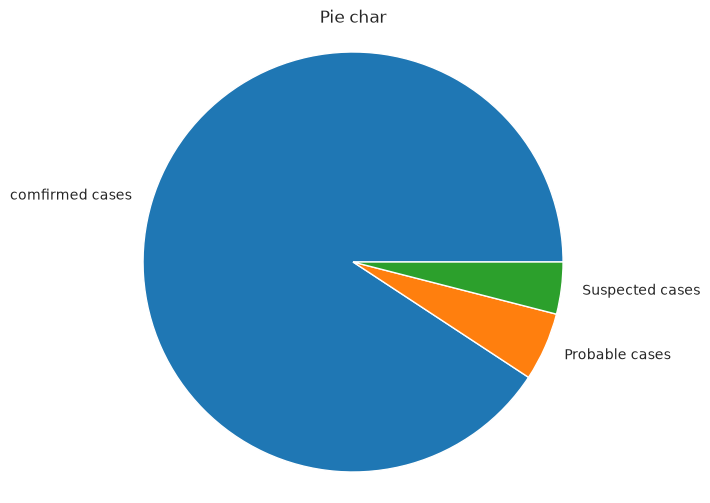

In [11]:
#parametros fixos
plt.rcParams['figure.figsize'] = [8,6]


sns.set_style('darkgrid')

plt.pie(sizes, labels=labels)
plt.title('Pie chart of Ebola deaths in Sierra Leone')
plt.axis('equal')
plt.show()

Podemos melhorar esse gráfico, mostrando a porcentagem de cada fatia (autopct='%1.1f%%), colocando uma sombra (shadow=True) e mudando o arranjo das fatias de pizza (startangle=90)

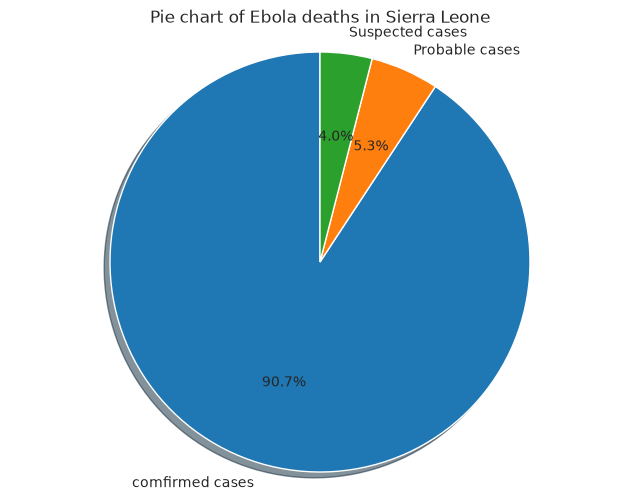

In [12]:
plt.pie(sizes, labels=labels,autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Pie chart of Ebola deaths in Sierra Leone')
plt.axis('equal')
plt.show()

## Gráfico de pizza lado a lado
Para comparar dois gráficos de pizza é interessante plotá-los lado a lado. Vamos usar o dataframe Ebola para comparar os dados de Guinea e Sierra Leone.

Já temos os um dataframe com os dados de Sierra Leone. Vamos criar um dataframe para armazenar os dados de Guinea.

In [13]:
guinea = df[df['Countries'] =='Guinea']

Vamos agora definir o tamanho do nosso gráfico em 12x8.

In [20]:
plt.rcParams['figure.figsize'] = [12,8]

sizes_sierra = sierra['Death']
sizes_guinea = guinea['Death']
labels_sierra = sierra['Type']
labels_guinea = guinea['Type']

Vamos agora definir sizes e labels para os dois gráficos. 

Agora vamos plotar os gráficos usando plt.subplot(lin, col, pos).

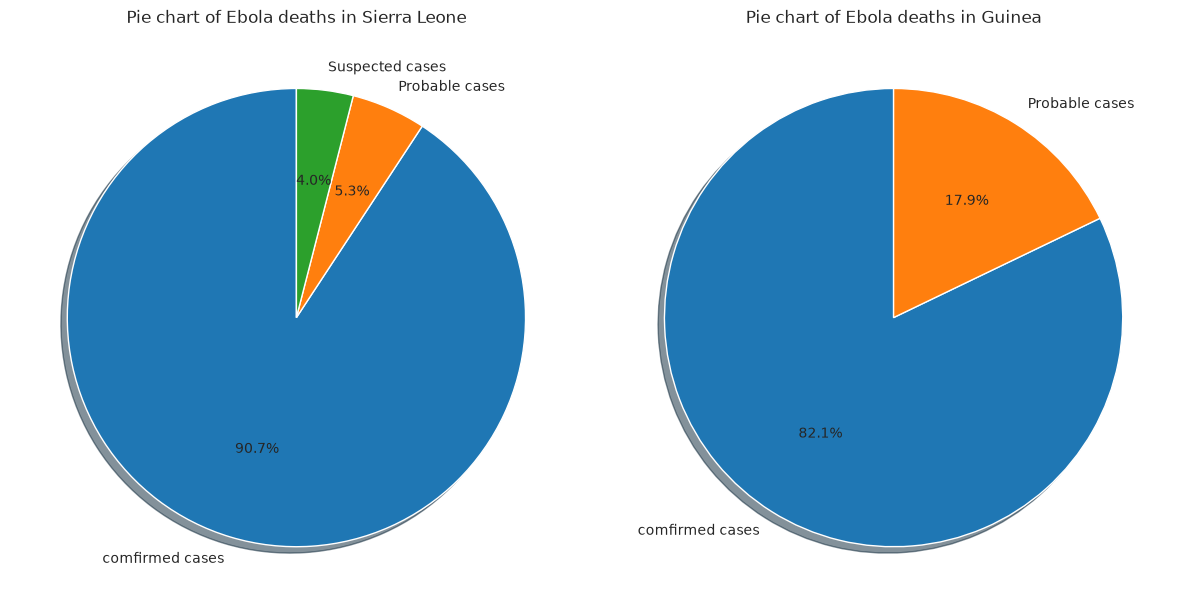

In [23]:

#linha coluna e posição

plt.subplot(1,2,1)
plt.pie(sizes_sierra, labels=labels_sierra,autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Pie chart of Ebola deaths in Sierra Leone')


plt.subplot(1,2,2)
plt.pie(sizes_guinea, labels=labels_guinea,autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Pie chart of Ebola deaths in Guinea')

plt.tight_layout()
plt.show()



### Exercício
Considere o dataset survey2021, que contém as respostas de um questionário respondido por desenvolvedores do software sobre suas atuações profissionais. 

In [25]:
df = pd.read_csv('datasets/survey2021.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83439 entries, 0 to 83438
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ResponseId                    83439 non-null  int64  
 1   MainBranch                    83439 non-null  str    
 2   Employment                    83323 non-null  str    
 3   Country                       83439 non-null  str    
 4   US_State                      14920 non-null  str    
 5   UK_Country                    4418 non-null   str    
 6   EdLevel                       83126 non-null  str    
 7   Age1stCode                    83243 non-null  str    
 8   LearnCode                     82963 non-null  str    
 9   YearsCode                     81641 non-null  str    
 10  YearsCodePro                  61216 non-null  str    
 11  DevType                       66484 non-null  str    
 12  OrgSize                       60726 non-null  str    
 13  Currency    

Vamos usar a coluna *LanguageHaveWorkedWith* para saber quais as linguagens de programação mais populares em 2021.

In [ ]:
df['LanguageHaveWorkedWith']

,LanguageHaveWorkedWith
0,C++;HTML/CSS;JavaScript;Objective-C;PHP;Swift
1,JavaScript;Python
2,Assembly;C;Python;R;Rust
3,JavaScript;TypeScript
4,Bash/Shell;HTML/CSS;Python;SQL
...,...
83434,Clojure;Kotlin;SQL
83435,NaN
83436,Groovy;Java;Python
83437,Bash/Shell;JavaScript;Node.js;Python


Temos que *LanguageHaveWorkedWith* possui 82.357 registros não nulos, ou seja, 82.357 declararam que trabalharam com alguma linguagem de programação. Note que a maioria trabalhou com 2 ou mais linguagens. Queremos saber o número de pessoas que trabalharam com Python, Javascript, Node.js, Java e SQL, bem como o número de pessoas que não trabalharam com nenhuma dessas linguagens.

Para isso, utilizaremos o método `str.contains` do Pandas (usado para verificar se um padrão ou texto está contido em uma string de uma Series). Em nosso exemplo, a lista de linguagens constitui o padrão. Em seguida, aplicaremos esse padrão ao DataFrame e obteremos as dimensões (*shape*) correspondentes a cada linguagem.

In [ ]:
# Lista com as linguagens que serão pesquisadas no DataFrame
language_list = ['Python', 'SQL', 'Javascript', 'Node.js', 'Java']

# Percorre cada linguagem da lista
for item in language_list:

    # .str.contains(item) verifica se o texto da coluna
    # 'LanguageHaveWorkedWith' contém o valor armazenado em 'item'.
    #
    # na=False faz com que os valores ausentes (NaN) sejam tratados
    # como False, evitando erros e indicando que não contêm a linguagem.
    #
    # O resultado é uma Série booleana, por exemplo:
    # True, False, True, ...
    filtro = df['LanguageHaveWorkedWith'].str.contains(item, na=False)

    # df.loc[linhas, colunas] seleciona partes específicas do DataFrame.
    #
    # Aqui:
    # - filtro define quais linhas serão selecionadas;
    # - 'LanguageHaveWorkedWith' define a coluna selecionada.
    #
    # .shape retorna o formato do resultado:
    # (quantidade_de_linhas, quantidade_de_colunas)
    #
    # Como apenas uma coluna foi selecionada, o resultado será algo como:
    # (150, 1)
    print(
        item,
        ":",
        df.loc[filtro, 'LanguageHaveWorkedWith'].shape
    )


# O operador ~ é usado para inverter valores booleanos:
# True  vira False
# False vira True
#
# Portanto, filtro_2 seleciona as linhas em que a coluna
# NÃO contém o valor armazenado em 'item'.
#
# Atenção: fora do laço for, 'item' mantém o último valor percorrido,
# que neste caso é 'Java'.
filtro_2 = ~df['LanguageHaveWorkedWith'].str.contains(item, na=False)

# Seleciona as linhas que não contêm a última linguagem pesquisada
# e mostra o formato do resultado.
print(
    'Nenhuma das anteriores',
    df.loc[filtro_2, 'LanguageHaveWorkedWith'].shape
)


In [43]:
language_list = ['Python', 'SQL', 'JavaScript', 'Node.js', 'C++']
for item in language_list:
    #not a non
    filtro = df['LanguageHaveWorkedWith'].str.contains(item, na=False)
    #formato do dataframe formado
    print(item, ":", df.loc[filtro, 'LanguageHaveWorkedWith'].shape)
#é tipo o complemento ~

Python : (39792,)
SQL : (38835,)
JavaScript : (53587,)
Node.js : (27975,)
C++ : (64021,)


Agora podemos criar nosso gráfico de pizza e mostrar as linguagens de programação mais populares em 2021.

In [44]:
labels = language_list.copy()
sizes =[]
for item in language_list:
    #not a non
    filtro = df['LanguageHaveWorkedWith'].str.contains(item, na=False)
    #formato do dataframe formado
    sizes.append(df.loc[filtro, 'LanguageHaveWorkedWith'].shape[0])

sizes

[39792, 38835, 53587, 27975, 64021]

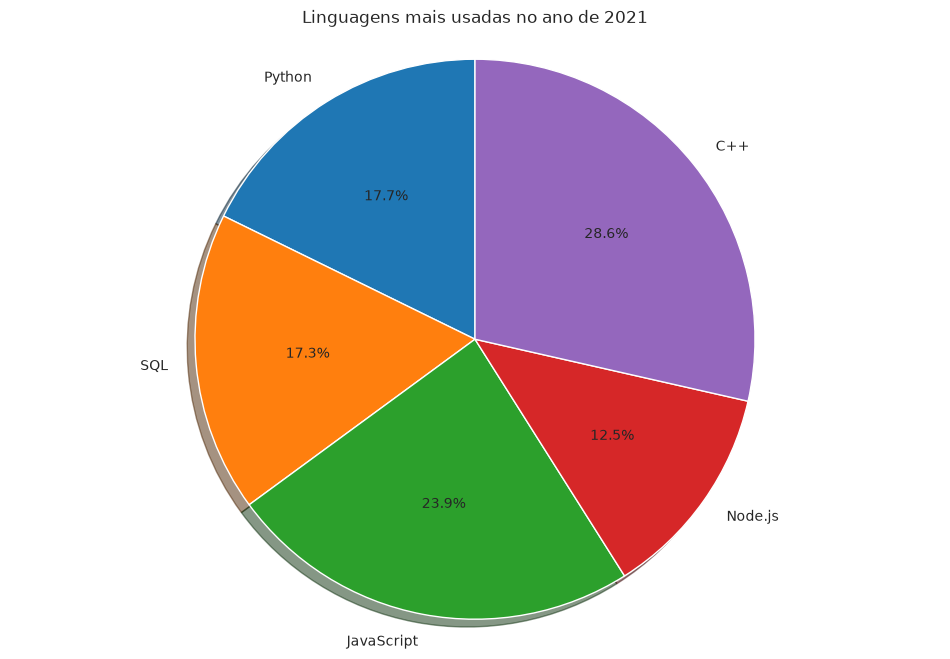

In [45]:
plt.rcParams['figure.figsize'] = [12,8]
plt.pie(sizes, labels=labels,autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Linguagens mais usadas no ano de 2021')
plt.axis('equal')
plt.show()